# **Customer Cohort Retention Analysis: Superstore Dataset 2014-2017**

### **Business Problem Understanding**

Perusahaan ritel Superstore menjual berbagai produk keperluan kantor dan sekolah dengan tiga kategori utama, yaitu *Furniture*, *Office Supplies*, dan *Technology*. Superstore menjangkau tiga segmen customer, yaitu *Consumer*, *Corporate*, dan *Home Office*, dalam skala nasional. Mempertahankan customer yang sudah ada terbukti lebih efisien secara biaya dibandingkan mendapatkan customer baru. Oleh karena itu, memahami pola loyalitas atau retensi customer secara keseluruhan dari waktu ke waktu menjadi krusial untuk keberlanjutan bisnis.

Saat ini, Superstore menghadapi tantangan dalam merancang strategi promosi yang efektif karena belum memiliki pemahaman yang mendalam tentang perilaku loyalitas customer secara umum. Beberapa pertanyaan kunci yang perlu dijawab untuk mengatasi tantangan ini adalah:

1. Bagaimana perilaku loyalitas customer Superstore secara keseluruhan dari waktu ke waktu berdasarkan dataset tahun 2014-2017?
2. Pada periode (kuartal) mana saja terjadi penurunan retensi yang signifikan?
3. Strategi apa yang perlu dilakukan untuk mencegah penurunan retensi customer?

### **Goals**

Berdasarkan permasalahan di atas, analisis ini bertujuan untuk:

1. Menganalisis tingkat retensi customer (cohort retention rate) secara keseluruhan dan periodik (per kuartal) selama tahun 2014-2017.
2. Menemukan pola umum dan titik-titik kritis di mana terjadi penurunan retensi terbesar pada basis customer Superstore.
3. Menyusun rekomendasi strategi promosi dan engagement yang data-driven untuk meningkatkan retensi customer secara keseluruhan di masa mendatang.

### **Analytical Approach**

Untuk mencapai tujuan yang telah ditetapkan, analisis ini akan menggunakan pendekatan kuantitatif dengan metode **Cohort Analysis**. Metode ini dipilih karena kemampuannya untuk melacak perilaku sekelompok pengguna (kohort) secara spesifik sepanjang siklus hidup mereka. Dalam konteks ini, customer akan dikelompokkan ke dalam kohort berdasarkan periode pertama mereka melakukan pembelian (kuartal akuisisi). Pendekatan ini memungkinkan kita untuk memahami bagaimana loyalitas customer baru terbentuk dan bagaimana perilaku mereka berkembang seiring waktu.

Periode analisis yang digunakan adalah **per kuartal**. Periode ini dipilih dengan mempertimbangkan jenis produk yang dijual Superstore (perlengkapan kantor dan sekolah) yang umumnya memiliki siklus pembelian lebih panjang, tidak bersifat harian atau bulanan. Dengan demikian, periode kuartalan (3 bulan) merupakan jangka waktu yang masuk akal untuk mengukur apakah seorang customer melakukan pembelian ulang.

Metrik utama yang akan digunakan adalah Retention Rate, yang didefinisikan sebagai persentase customer dari suatu kohort yang melakukan pembelian kembali di kuartal-kuartal berikutnya. Seorang customer dinyatakan "bertahan" atau retained jika ia melakukan setidaknya satu transaksi di kuartal tersebut.

Hasil dari analisis ini akan divisualisasikan dalam bentuk cohort retention table dan heatmap untuk memudahkan identifikasi pola, tren, serta anomali dalam perilaku retensi customer Superstore secara keseluruhan. Temuan-temuan ini kemudian akan menjadi dasar dalam merumuskan rekomendasi strategi bisnis yang tepat sasaran.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas_gbq
from google.oauth2 import service_account
pd.set_option('display.max_rows', 100)

## 1. Import Data & EDA

In [2]:
df=pd.read_csv(r"D:\Purwadika\Data Set\Sample - Superstore.csv", parse_dates=["Order Date"])
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [4]:
display(df.describe(include='number'),df.describe(exclude='number'))

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,NaN,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,NaN,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,NaN,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48
mean,NaN,2016-04-30 00:07:12.259355648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2014-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2015-05-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2016-06-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2017-05-14 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2017-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Hasil eksplorasi data menunjukkan bahwa dataset Superstore terbebas dari nilai kosong, khususnya pada kolom Order Date dan Ship Date. Kelengkapan kedua kolom ini menjadi indikator bahwa seluruh transaksi berhasil diproses tanpa pembatalan. Dengan demikian, analisis dapat dilanjutkan untuk fokus pada pola retensi pembelian di Superstore.

### A. Cek Total Customer per Region

In [7]:
cust_per_reg = (
    df.groupby('Region')['Customer ID'].nunique().reset_index(name='customer_count')
)
cust_per_reg

,Region,customer_count
0,Central,629
1,East,674
2,South,512
3,West,686


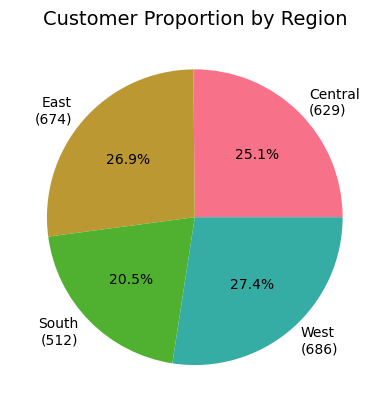

In [8]:
# Buat label yang menampilkan segment dan count
labels = [f"{region}\n({count:,})" 
          for region, count in zip(cust_per_reg['Region'], 
                                   cust_per_reg['customer_count'])]

plt.pie(x=cust_per_reg['customer_count'], 
        labels=labels,
        autopct='%.1f%%', 
        colors=sns.color_palette('husl'))
plt.title('Customer Proportion by Region', size=14)
plt.show()

Berdasarkan bar plot di atas, Office Supplies merupakan kategori produk dengan total pembelian tertinggi di Superstore, diikuti oleh Furniture dan Technology. Hal ini menunjukkan bahwa Office Supplies adalah kategori produk paling laris di Superstore secara keseluruhan.

### B. Cek Distribusi Produk

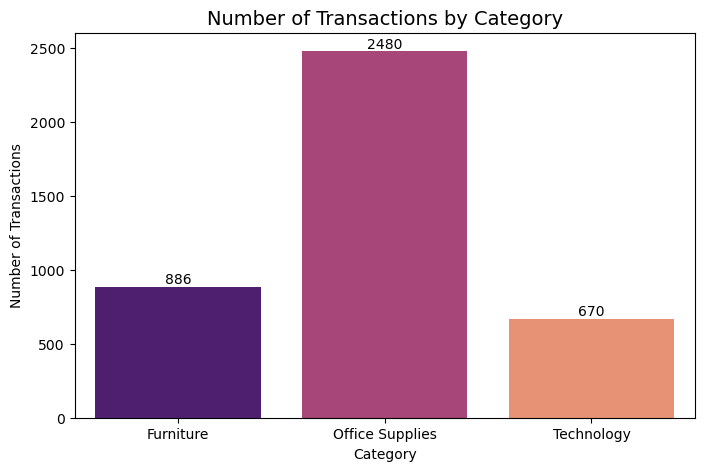

In [27]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Category', palette='magma')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Number of Transactions by Category', size=14)
plt.xlabel('Category')
plt.ylabel('Number of Transactions')

plt.show()

___

## 2. Cohort Analysis : Data Preprocessing

Untuk memahami perilaku loyalitas customer dari waktu ke waktu, dilakukan analisis kohort dengan mendefinisikan customer yang bertahan (retained) sebagai customer yang melakukan minimal satu transaksi dalam satu kuartal (3 bulan) setelah kuartal transaksi pertamanya. Periode kuartal dipilih karena sesuai dengan siklus pembelian produk ritel Superstore yang tidak bersifat harian maupun bulanan.

Dalam mempersiapkan data untuk analisis ini, beberapa kolom utama perlu dibentuk guna mengelompokkan customer berdasarkan kuartal akuisisi pertama dan melacak aktivitas transaksi mereka di kuartal-kuartal berikutnya:

1. `Cohort_Quarter` : Menandai kuartal pertama kali seorang customer melakukan transaksi. Kolom ini menjadi dasar pengelompokan customer ke dalam kohort yang sama.

2. `Current_Transaction_Quarter` : Menunjukkan kuartal observasi atau periode transaksi yang sedang dianalisis. Kolom ini digunakan untuk melihat apakah customer masih melakukan transaksi di periode-periode setelah kuartal pertamanya.

3. `Count_Customer` : Menghitung jumlah unik customer dalam setiap kombinasi `Cohort_Quarter` dan `Current_Transaction_Quarter`, yang nantinya akan digunakan untuk menghitung tingkat retensi.

4. `Quarter_Distance` : Merepresentasikan selisih waktu (dalam kuartal) antara `Current_Transaction_Quarter` dengan `Cohort_Quarter`. Kolom ini penting untuk membandingkan perilaku customer pada fase usia yang sama antar kohort yang berbeda.



### Step 1 : Define cohort period

In [9]:
df['Cohort_Quarter'] = df.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('Q')       # transform('min'): cetak ulang yg paling awal
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Cohort_Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2015Q4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2015Q4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016Q2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015Q4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015Q4


### Step 2 : Define current transaction period

In [10]:
df['Current_Transaction_Quarter']=df['Order Date'].dt.to_period('Q')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Cohort_Quarter,Current_Transaction_Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2015Q4,2016Q4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2015Q4,2016Q4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016Q2,2016Q2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015Q4,2015Q4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015Q4,2015Q4


In [11]:
df = df.drop_duplicates(['Customer ID','Current_Transaction_Quarter'])

### Step 3 : Choose columns
Kolom Customer ID diperlukan untuk menghitung banyaknya customer dan kolom Segment diperlukan untuk pembagian segmentasi customer pada step selanjutnya.

In [12]:
df_retention=df[['Customer ID', 'Order Date', 'Cohort_Quarter', 'Current_Transaction_Quarter']]
df_retention

,Customer ID,Order Date,Cohort_Quarter,Current_Transaction_Quarter
0,CG-12520,2016-11-08,2015Q4,2016Q4
2,DV-13045,2016-06-12,2016Q2,2016Q2
3,SO-20335,2015-10-11,2015Q4,2015Q4
5,BH-11710,2014-06-09,2014Q2,2014Q2
12,AA-10480,2017-04-15,2014Q2,2017Q2
...,...,...,...,...
9972,RC-19960,2016-09-11,2014Q3,2016Q3
9980,SW-20455,2015-09-06,2015Q2,2015Q3
9984,DV-13465,2015-05-17,2014Q2,2015Q2
9986,ML-17410,2016-09-29,2014Q4,2016Q3


In [13]:
# df[df.duplicated()]

Tabel di atas menunjukkan adanya duplikasi data customer. Kita perlu menghapus duplikasi data customer karena customer dianggap bertahan apabila melakukan (minimal) satu kali pembelian dalam satu kuartal secara beruturut-turut.

In [14]:
# df=df.drop_duplicates()
# df

### Step 4 : Aggregate columns for the total customers per quarter

Pada langkah berikut, kami menghitung jumlah customer berdasarkan segmen, kuartal customer melakukan pembelian, dan kuartal saat ini.

In [15]:
df_retention = (df.groupby(['Cohort_Quarter', 'Current_Transaction_Quarter'])['Customer ID'].nunique().reset_index(name='Count_Customer'))
df_retention

,Cohort_Quarter,Current_Transaction_Quarter,Count_Customer
0,2014Q1,2014Q1,121
1,2014Q1,2014Q2,20
2,2014Q1,2014Q3,28
3,2014Q1,2014Q4,41
4,2014Q1,2015Q1,18
...,...,...,...
129,2017Q2,2017Q2,2
130,2017Q2,2017Q4,1
131,2017Q3,2017Q3,3
132,2017Q3,2017Q4,1


### Step 5 : Define period distance (quarter)

Selanjutnya, untuk membagi jarak semua kuartal dengan tepat, diperlukan kolom Quarter_Distance.

In [16]:
df_retention['Quarter_Distance'] = (
    (df_retention['Current_Transaction_Quarter'].dt.year 
     - df_retention['Cohort_Quarter'].dt.year) * 4
    +
    (df_retention['Current_Transaction_Quarter'].dt.quarter 
     - df_retention['Cohort_Quarter'].dt.quarter))
df_retention

,Cohort_Quarter,Current_Transaction_Quarter,Count_Customer,Quarter_Distance
0,2014Q1,2014Q1,121,0
1,2014Q1,2014Q2,20,1
2,2014Q1,2014Q3,28,2
3,2014Q1,2014Q4,41,3
4,2014Q1,2015Q1,18,4
...,...,...,...,...
129,2017Q2,2017Q2,2,0
130,2017Q2,2017Q4,1,2
131,2017Q3,2017Q3,3,0
132,2017Q3,2017Q4,1,1


In [17]:
# save to csv
# df_retention.to_csv('df_retention (precapstone).csv',index=0)

### Step 6 : Pivot Table

In [18]:
df_retention_pivot=df_retention.pivot_table(index='Cohort_Quarter',columns='Quarter_Distance', values='Count_Customer')
df_retention_pivot

Quarter_Distance,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Cohort_Quarter,,,,,,,,,,,,,,,,
2014Q1,121.0,20.0,28.0,41.0,18.0,27.0,33.0,45.0,26.0,34.0,43.0,53.0,34.0,49.0,51.0,66.0
2014Q2,160.0,39.0,58.0,28.0,44.0,47.0,68.0,33.0,51.0,57.0,78.0,37.0,58.0,72.0,85.0,NaN
2014Q3,161.0,53.0,30.0,46.0,48.0,67.0,30.0,48.0,64.0,70.0,37.0,63.0,72.0,84.0,NaN,NaN
2014Q4,153.0,27.0,31.0,48.0,61.0,30.0,50.0,58.0,63.0,42.0,56.0,64.0,95.0,NaN,NaN,NaN
2015Q1,32.0,8.0,10.0,8.0,6.0,6.0,12.0,16.0,12.0,12.0,7.0,16.0,NaN,NaN,NaN,NaN
2015Q2,36.0,11.0,14.0,10.0,10.0,16.0,16.0,13.0,7.0,20.0,21.0,NaN,NaN,NaN,NaN,NaN
2015Q3,36.0,15.0,10.0,8.0,14.0,16.0,9.0,19.0,19.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN
2015Q4,32.0,3.0,5.0,11.0,12.0,12.0,6.0,13.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016Q1,14.0,6.0,6.0,7.0,8.0,6.0,9.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 7 : Convert value to percentage

In [19]:
df_retention_final=df_retention_pivot.divide(df_retention_pivot.iloc[:,0],axis=0)
df_retention_final

Quarter_Distance,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Cohort_Quarter,,,,,,,,,,,,,,,,
2014Q1,1.0,0.165289,0.231405,0.338843,0.148760,0.223140,0.272727,0.371901,0.214876,0.280992,0.355372,0.438017,0.280992,0.404959,0.421488,0.545455
2014Q2,1.0,0.243750,0.362500,0.175000,0.275000,0.293750,0.425000,0.206250,0.318750,0.356250,0.487500,0.231250,0.362500,0.450000,0.531250,NaN
2014Q3,1.0,0.329193,0.186335,0.285714,0.298137,0.416149,0.186335,0.298137,0.397516,0.434783,0.229814,0.391304,0.447205,0.521739,NaN,NaN
2014Q4,1.0,0.176471,0.202614,0.313725,0.398693,0.196078,0.326797,0.379085,0.411765,0.274510,0.366013,0.418301,0.620915,NaN,NaN,NaN
2015Q1,1.0,0.250000,0.312500,0.250000,0.187500,0.187500,0.375000,0.500000,0.375000,0.375000,0.218750,0.500000,NaN,NaN,NaN,NaN
2015Q2,1.0,0.305556,0.388889,0.277778,0.277778,0.444444,0.444444,0.361111,0.194444,0.555556,0.583333,NaN,NaN,NaN,NaN,NaN
2015Q3,1.0,0.416667,0.277778,0.222222,0.388889,0.444444,0.250000,0.527778,0.527778,0.416667,NaN,NaN,NaN,NaN,NaN,NaN
2015Q4,1.0,0.093750,0.156250,0.343750,0.375000,0.375000,0.187500,0.406250,0.531250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016Q1,1.0,0.428571,0.428571,0.500000,0.571429,0.428571,0.642857,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Cohort Analysis : Data Visualization Heatmap

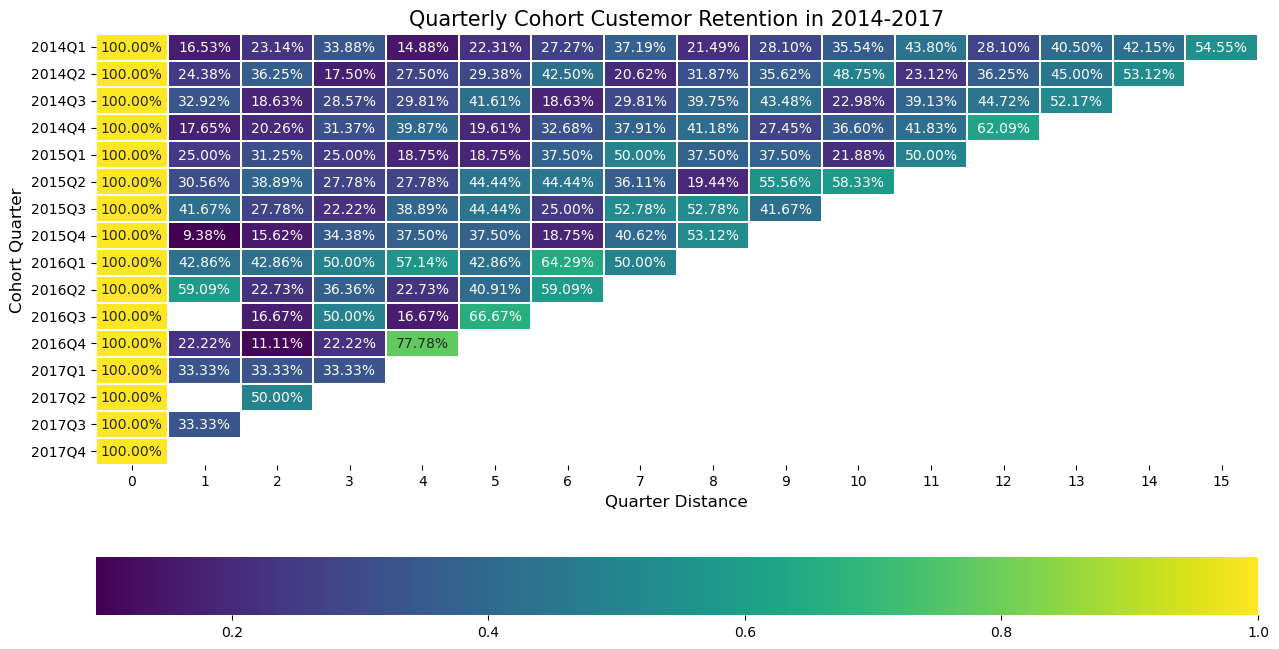

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(data=df_retention_final,annot=True,fmt='.2%',cmap='viridis',
           cbar_kws={'orientation':'horizontal'},linewidths=0.01
           )
plt.xlabel('Quarter Distance',size=12)
plt.ylabel('Cohort Quarter',size=12)
plt.title('Quarterly Cohort Custemor Retention in 2014-2017',size=15)
plt.show()

## 4. Cohort Analysis : Data Visualization Lineplot

In [21]:
# Consumer
cohort_lineplot=pd.melt(
    df_retention_final.reset_index(),
    id_vars='Cohort_Quarter',
    var_name='Quarter_Distance',
    value_name='percentage'
).dropna()
cohort_lineplot

,Cohort_Quarter,Quarter_Distance,percentage
0,2014Q1,0,1.000000
1,2014Q2,0,1.000000
2,2014Q3,0,1.000000
3,2014Q4,0,1.000000
4,2015Q1,0,1.000000
...,...,...,...
209,2014Q2,13,0.450000
210,2014Q3,13,0.521739
224,2014Q1,14,0.421488
225,2014Q2,14,0.531250


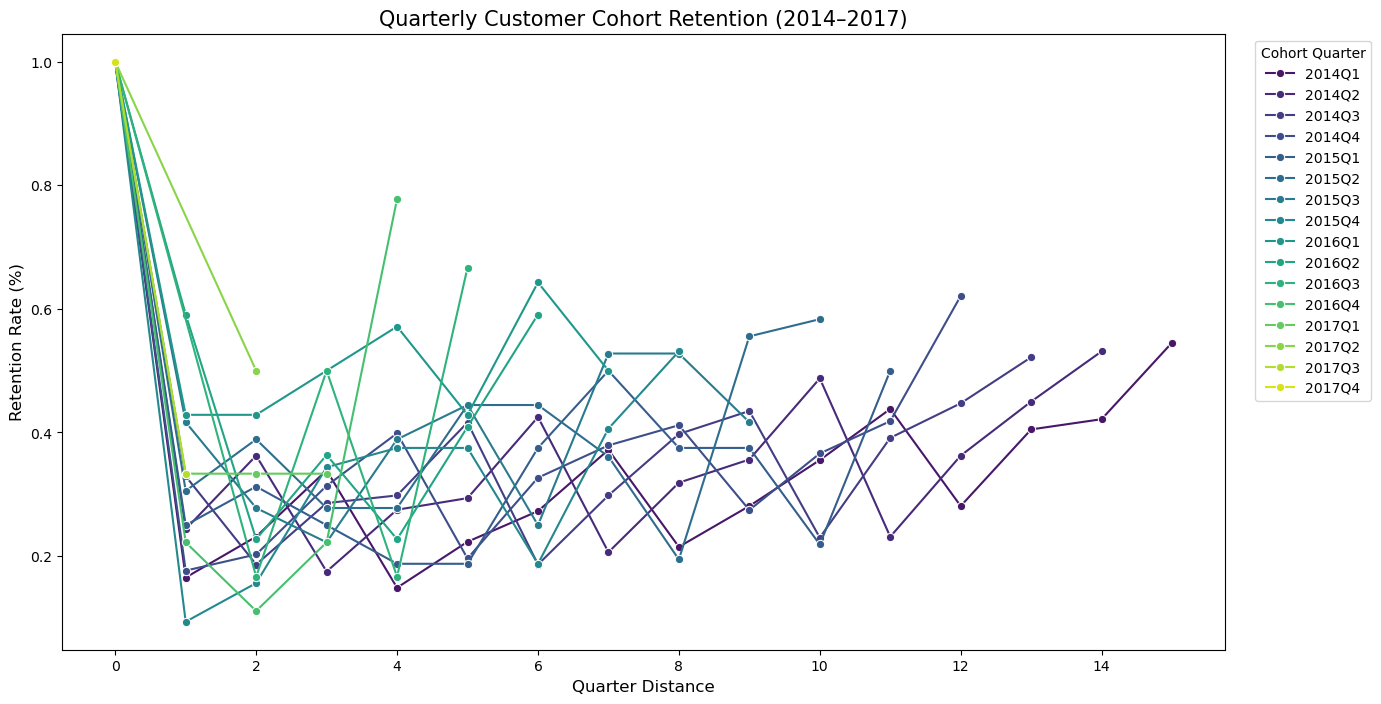

In [23]:
plt.figure(figsize=(15,8))

sns.lineplot(
    data=cohort_lineplot,
    x='Quarter_Distance',
    y='percentage',
    hue='Cohort_Quarter',
    palette='viridis',
    marker='o'
)

plt.xlabel('Quarter Distance', size=12)
plt.ylabel('Retention Rate (%)', size=12)
plt.title('Quarterly Customer Cohort Retention (2014–2017)', size=15)

plt.legend(title='Cohort Quarter', bbox_to_anchor=(1.02,1), loc='upper left')

plt.show()

___

## **Insight**

Berdasarkan cohort retention heatmap dan lineplot, terlihat bahwa semua cohort memiliki pola yang sama yaitu penurunan retention yang cukup tajam setelah quarter pertama. Pada quarter ke-0 seluruh cohort memiliki nilai retention 100%, karena merupakan periode pertama customer melakukan transaksi. Pada Quarter 1 retention langsung turun ke kisaran 15%–35%. Artinya sekitar 65%–85% pelanggan tidak kembali bertransaksi setelah pembelian pertama. Ini menunjukkan repeat purchase behavior terhadap 1 quarter masih rendah.

Retention jangka panjang cenderung fluktuatif dan tidak stabil. Pada quarter berikutnya, retention berfluktuasi di kisaran 20%–50%. Hampir tidak ada cohort yang mempertahankan retention secara konsisten di atas 50%. Hal ini menunjukkan loyalitas pelanggan belum kuat.

Beberapa cohort menunjukkan peningkatan retention sementara. Contohnya 2016Q4 cohort menunjukkan retention tinggi hingga 77.78% di Quarter 4. 2016Q3 cohort mencapai 66.67% pada Quarter 5. Ini kemungkinan terjadi karena adanya promo tertentu, seasonal demand, pembelian ulang pada periode tertentu. Namun sayangnya pola ini tidak terjadi secara konsisten di semua cohort.

Cohort pada periode awal memiliki pola retention lebih stabil. Seperti pada 2014Q1, 2014Q2, 2015Q1 yang menunjukkan retention jangka panjang yang relatif stabil di kisaran 30%–50%. Ini mengindikasikan bahwa pelanggan yang bertahan setelah beberapa periode cenderung menjadi pelanggan loyal.

## **Analysis**

Berdasarkan pola cohort retention, terdapat beberapa indikasi perilaku pelanggan

**Low Early Retention**

Penurunan drastis setelah quarter pertama menunjukkan bahwa sebagian besar pelanggan melakukan one-time purchase. Kemungkinan penyebabnya adalah :
- pelanggan hanya membeli ketika ada kebutuhan tertentu
- kurangnya engagement setelah pembelian pertama
- kurangnya strategi retensi pelanggan

**Irregular Repeat Purchase Pattern**

Fluktuasi retention di beberapa cohort menunjukkan bahwa pembelian ulang tidak terjadi secara rutin, melainkan sporadis. Hal ini sering terjadi karena:
- retail non-subscription (Tidak adanya membership pembeli)
- produk kebutuhan tidak rutin
- pelanggan yang sensitif terhadap promo (Adanya promosi atau diskon pada periode tertentu)

**Potential Loyal Customer Segment**

Cohort yang mampu mempertahankan retention di atas 40% setelah beberapa quarter menunjukkan adanya segmen pelanggan loyal. Ini adalah customer segment yang harus dipertahankan loyalitasnya.

## **Conclusion**

Berdasarkan cohort retention analysis periode 2014–2017, terlihat bahwa:

- Sebagian besar pelanggan tidak melakukan pembelian ulang setelah transaksi pertama.
- Retention rate mengalami penurunan signifikan pada quarter pertama.
- Meskipun terdapat beberapa cohort dengan retention tinggi, pola tersebut tidak konsisten di seluruh cohort.
- Hal ini menunjukkan bahwa perusahaan masih memiliki peluang besar untuk meningkatkan customer retention dan loyalty.

Dengan menerapkan strategi retensi seperti loyalty program, personalisasi strategi marketing, dan repeat purchase behavior, perusahaan berpotensi meningkatkan customer lifetime value dan stabilitas pendapatan jangka panjang.

## **Recommendation**

Berdasarkan hasil analisis cohort retention, beberapa strategi yang dapat dilakukan untuk meningkatkan retensi pelanggan antara lain:

**1. Fokus meningkatkan retention setelah pembelian pertama**

    Karena penurunan terbesar terjadi setelah Quarter 1, strategi utama harus difokuskan pada post-first purchase engagement.

    Contoh strategi:
    - welcome email campaign
    - first repeat purchase discount
    - follow-up promotion

**2. Implement loyalty program**

    Tujuannya untuk meningkatkan customer lifetime value.

    Membuat program seperti:
    - reward points
    - membership program
    - cashback untuk repeat purchase

**3. Personalisasi strategi marketing**

    Ini dapat meningkatkan kemungkinan repeat purchase.

    Gunakan data pembelian pelanggan untuk:
    - memberikan product recommendation
    - mengirim targeted promotion
    - membuat segment-based campaign

**4. Identify high-retention cohorts**

    Cohort seperti 2016Q3 dan 2016Q4 menunjukkan retention tinggi.

    Perusahaan dapat:
    - menganalisis faktor penyebab
    - melihat campaign atau kondisi pada periode tersebut
    - mereplikasi strategi tersebut di periode berikutnya.